## Unicode is a text encoding standard that maps characters to integer code points

In [1]:
ord("a")

97

In [3]:
ord("%")

37

In [5]:
#What Unicode character does chr(0) return?
chr(0)

'\x00'

In [3]:
import torch

def get_memory_usage(x: torch.Tensor):
    return x.numel() * x.element_size()

In [5]:
import torch
x = torch.zeros (4, 8) # @inspect x
assert x.dtype == torch.float32 # Default type
assert x.size() == torch.Size([4, 8])

assert x.numel () == 4 * 8

assert x. element_size() == 4 # Float is 4 bytes

assert get_memory_usage (x) == 4 * 8 * 4
#A128 bytes

What happens when this character occurs in text? It may be helpful to play around with the
following in your Python interpreter and see if it matches your expectations:
```
>>> chr(0)
>>> print(chr(0))
>>> "this is a test" + chr(0) + "string"
>>> print("this is a test" + chr(0) + "string")
```
Deliverable: A one-sentence response.

The chr(0) character represents the null character (\x00), which is invisible in output, acts as a string terminator in some languages, and can cause unexpected behavior in string processing or file handling.

In [2]:
test_string = "hello! こんにちは!"

In [3]:
utf8_encoded = test_string.encode("utf-8")

In [4]:
print(utf8_encoded)

b'hello! \xe3\x81\x93\xe3\x82\x93\xe3\x81\xab\xe3\x81\xa1\xe3\x81\xaf!'


In [5]:
print(type(utf8_encoded))

<class 'bytes'>


In [6]:
list(utf8_encoded)

[104,
 101,
 108,
 108,
 111,
 33,
 32,
 227,
 129,
 147,
 227,
 130,
 147,
 227,
 129,
 171,
 227,
 129,
 161,
 227,
 129,
 175,
 33]

In [7]:
print(len(test_string))

13


In [8]:
print(len(utf8_encoded))

23


In [9]:
print(utf8_encoded.decode("utf-8"))

hello! こんにちは!


What are some reasons to prefer training our tokenizer on UTF-8 encoded bytes, rather than
UTF-16 or UTF-32? It may be helpful to compare the output of these encodings for various
input strings.

Answer: UTF-8 is preferred for training tokenizers because it is more space-efficient for common ASCII characters, widely supported across systems and tools, and preserves byte-alignment with no null bytes in ASCII, making it easier to process and stream compared to the fixed-width UTF-16 or UTF-32 encodings.









Ask ChatGPT


Consider the following (incorrect) function, which is intended to decode a UTF-8 byte string into
a Unicode string. Why is this function incorrect? Provide an example of an input byte string
that yields incorrect results.
```python
def decode_utf8_bytes_to_str_wrong(bytestring: bytes):
return ""
.join([bytes([b]).decode("utf-8") for b in bytestring])
>>> decode_utf8_bytes_to_str_wrong("hello".encode("utf-8"))
'hello'
```
Deliverable: An example input byte string for which decode_utf8_bytes_to_str_wrong pro-
duces incorrect output, with a one-sentence explanation of why the function is incorrect.

Example input: decode_utf8_bytes_to_str_wrong("€".encode("utf-8")) returns '���' instead of '€' because the function decodes each byte individually, which breaks multi-byte UTF-8 sequences that must be decoded as a whole.

Give a two byte sequence that does not decode to any Unicode character(s).
Deliverable: An example, with a one-sentence explanation.

Answer: Example: b'\xc3\x28' — this is an invalid UTF-8 sequence because 0xC3 expects a continuation byte in the range 0x80–0xBF, but 0x28 ('(') is not in that range.


In [15]:
import regex as re
PAT = r"""'(?:[sdmt]|ll|ve|re)| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+"""

In [16]:
re.findall(PAT, "some text that i'll pre-tokenize")

['some', ' text', ' that', ' i', "'ll", ' pre', '-', 'tokenize']

In [2]:
import torch
x = torch.tensor([[1., 2, 3], [4, 5, 6]])  # @inspect x
x = torch.zeros(4, 8)  # 4x8 matrix of all zeros @inspect x
x = torch.ones(4, 8)# 4x8 matrix of all ones @inspect x
x = torch.randn(4, 8)  # 4x8 matrix of iid Normal(0, 1) samples @inspect x

In [4]:
def get_memory_usage(x: torch.Tensor):
    return x.numel() * x.element_size()
x = torch.zeros(4, 8)  # @inspect x
assert x.dtype == torch.float32  # Default type
assert x.numel() == 4 * 8
assert x.element_size() == 4  # Float is 4 bytes
assert get_memory_usage(x) == 4 * 8 * 4  # 128 bytes

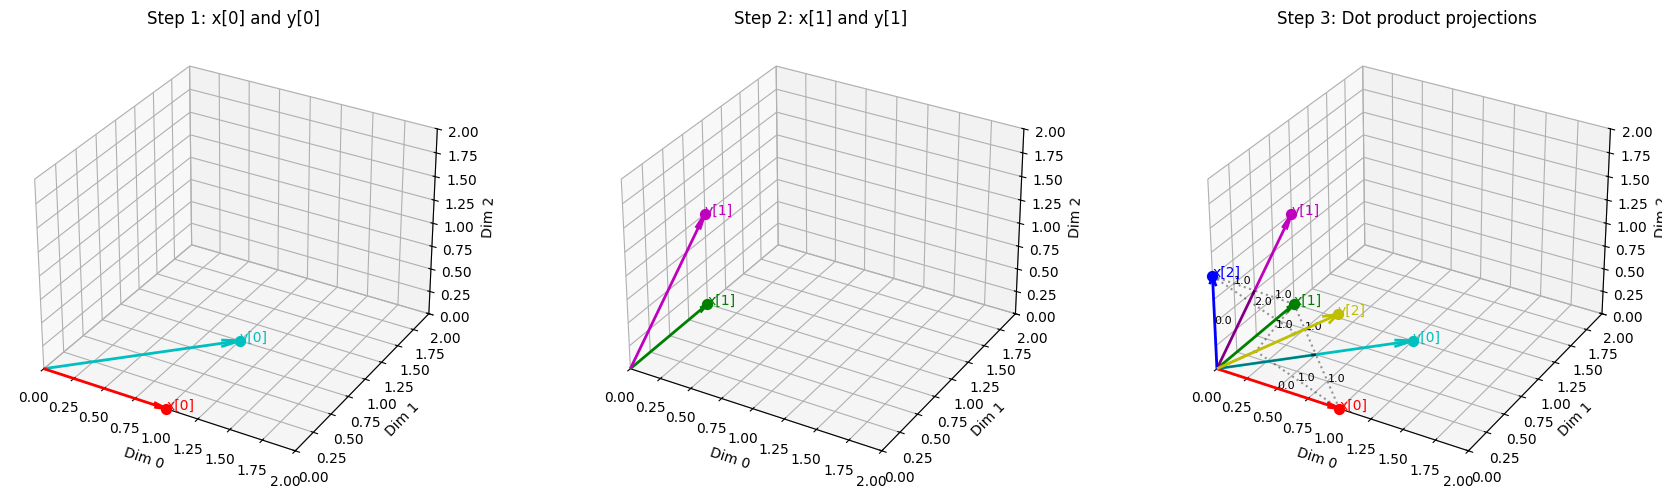

In [18]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 2x3x4 tensors
x = torch.tensor([[[1, 0, 0, 0],
                   [0, 1, 0, 1],
                   [0, 0, 1, 1]],
                  [[1, 1, 0, 0],
                   [0, 1, 1, 0],
                   [1, 0, 1, 1]]], dtype=torch.float)

y = torch.tensor([[[1, 1, 0, 0],
                   [0, 1, 1, 0],
                   [1, 0, 1, 1]],
                  [[1, 0, 0, 1],
                   [0, 1, 0, 1],
                   [0, 0, 1, 0]]], dtype=torch.float)

batch = 0
colors_x = ['r', 'g', 'b']
colors_y = ['c', 'm', 'y']

def plot_vector(ax, vec, color, label):
    ax.quiver(0,0,0, vec[0], vec[1], vec[2], color=color, linewidth=2, arrow_length_ratio=0.1)
    ax.scatter(vec[0], vec[1], vec[2], color=color, s=50)
    ax.text(vec[0], vec[1], vec[2], label, color=color)

# Create figure with 3 subplots
fig = plt.figure(figsize=(18,5))

# Step 1: Visualize first vector pair
ax1 = fig.add_subplot(131, projection='3d')
plot_vector(ax1, x[batch,0,:3], colors_x[0], 'x[0]')
plot_vector(ax1, y[batch,0,:3], colors_y[0], 'y[0]')
ax1.set_title('Step 1: x[0] and y[0]')
ax1.set_xlim([0,2]); ax1.set_ylim([0,2]); ax1.set_zlim([0,2])
ax1.set_xlabel('Dim 0'); ax1.set_ylabel('Dim 1'); ax1.set_zlabel('Dim 2')

# Step 2: Visualize second vector pair
ax2 = fig.add_subplot(132, projection='3d')
plot_vector(ax2, x[batch,1,:3], colors_x[1], 'x[1]')
plot_vector(ax2, y[batch,1,:3], colors_y[1], 'y[1]')
ax2.set_title('Step 2: x[1] and y[1]')
ax2.set_xlim([0,2]); ax2.set_ylim([0,2]); ax2.set_zlim([0,2])
ax2.set_xlabel('Dim 0'); ax2.set_ylabel('Dim 1'); ax2.set_zlabel('Dim 2')

# Step 3: Show dot product projections for first batch
ax3 = fig.add_subplot(133, projection='3d')
seq1, seq2 = x.shape[1], y.shape[1]

for i in range(seq1):
    plot_vector(ax3, x[batch,i,:3], colors_x[i], f'x[{i}]')
for j in range(seq2):
    plot_vector(ax3, y[batch,j,:3], colors_y[j], f'y[{j}]')

# Draw projections
for i in range(seq1):
    for j in range(seq2):
        dot = torch.dot(x[batch,i], y[batch,j]).item()
        proj = (dot / torch.dot(y[batch,j], y[batch,j]).item()) * y[batch,j]
        proj3d = proj[:3]
        # Line from tip of x[i] to projection
        x_tip = x[batch,i,:3]
        ax3.plot([x_tip[0], proj3d[0]], [x_tip[1], proj3d[1]], [x_tip[2], proj3d[2]],
                 color='k', linestyle=':', alpha=0.4)
        # Projection arrow
        ax3.quiver(0,0,0, proj3d[0], proj3d[1], proj3d[2], color='k', alpha=0.2, arrow_length_ratio=0.05)
        # Optional: show dot value
        mid = (x_tip + proj3d)/2
        ax3.text(mid[0], mid[1], mid[2], f'{dot:.1f}', color='k', fontsize=8)

ax3.set_title('Step 3: Dot product projections')
ax3.set_xlim([0,2]); ax3.set_ylim([0,2]); ax3.set_zlim([0,2])
ax3.set_xlabel('Dim 0'); ax3.set_ylabel('Dim 1'); ax3.set_zlabel('Dim 2')

plt.tight_layout()
plt.show()


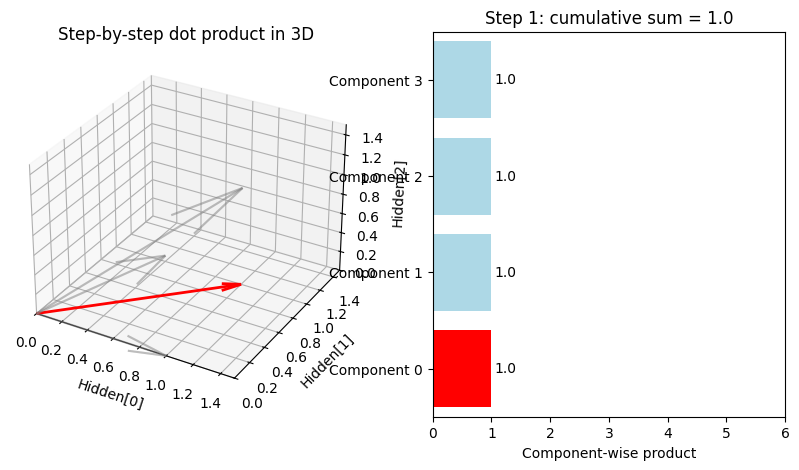

Final dot product: 4.0


In [20]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time

# Example vectors: batch=0, seq1=3, seq2=3, hidden=4
x = torch.ones(2,3,4)
y = torch.ones(2,3,4)
batch = 0

vec_x = x[batch,0]
vec_y = y[batch,0]
hidden = vec_x.shape[0]

# Colors for components
colors = ['r','g','b','orange']

fig = plt.figure(figsize=(10,5))

# 3D vector plot
ax = fig.add_subplot(121, projection='3d')
ax.set_xlim(0,1.5); ax.set_ylim(0,1.5); ax.set_zlim(0,1.5)
ax.set_xlabel('Hidden[0]'); ax.set_ylabel('Hidden[1]'); ax.set_zlabel('Hidden[2]')
ax.set_title('Step-by-step dot product in 3D')

# 2D component-wise bar plot
ax2 = fig.add_subplot(122)
ax2.set_xlim(0, hidden*1.5)
ax2.set_ylim(-0.5, hidden-0.5)
ax2.set_yticks(range(hidden))
ax2.set_yticklabels([f'Component {i}' for i in range(hidden)])
ax2.set_xlabel('Component-wise product')
ax2.set_title('Component-wise contribution')

cumsum = 0
for k in range(hidden):
    # Highlight current component in 3D
    ax.cla()
    ax.set_xlim(0,1.5); ax.set_ylim(0,1.5); ax.set_zlim(0,1.5)
    ax.set_xlabel('Hidden[0]'); ax.set_ylabel('Hidden[1]'); ax.set_zlabel('Hidden[2]')
    ax.set_title('Step-by-step dot product in 3D')

    # Draw x and y vectors
    for i in range(3):  # first 3 dims
        ax.quiver(0,0,0, vec_x[i], 0 if i>0 else vec_x[i], 0 if i>1 else vec_x[i], color='grey', alpha=0.3)
        ax.quiver(0,0,0, vec_y[i], 0 if i>0 else vec_y[i], 0 if i>1 else vec_y[i], color='grey', alpha=0.3)
    
    # Highlight current component in 3D
    ax.quiver(0,0,0, vec_x[k], vec_y[k], 0, color=colors[k], linewidth=2, arrow_length_ratio=0.1)

    # Update 2D component-wise bar plot
    product = vec_x[k]*vec_y[k]
    cumsum += product
    ax2.cla()
    ax2.set_xlim(0, hidden*1.5)
    ax2.set_ylim(-0.5, hidden-0.5)
    ax2.set_yticks(range(hidden))
    ax2.set_yticklabels([f'Component {i}' for i in range(hidden)])
    ax2.set_xlabel('Component-wise product')
    ax2.set_title(f'Step {k+1}: cumulative sum = {cumsum}')
    
    # Draw bars
    for i in range(hidden):
        color = colors[i] if i==k else 'lightblue'
        value = vec_x[i]*vec_y[i]
        ax2.barh(i, value, color=color)
        ax2.text(value+0.05, i, f'{value:.1f}', va='center')

    plt.pause(1)  # pause to see step

plt.show()
print(f'Final dot product: {cumsum}')
